## **Customer Churn Prediction & Risk Segmentation Dashboard**

## **TASK 1** — Data Loading & Exploratory Analysis




In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
telco = pd.read_csv('Telco_Customer_Churn.csv')

In [91]:
telco.shape

(7043, 21)

In [92]:
telco.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [93]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [94]:
telco.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [95]:
telco.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [96]:
telco['Churn']

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


Churn
No     5174
Yes    1869
Name: count, dtype: int64


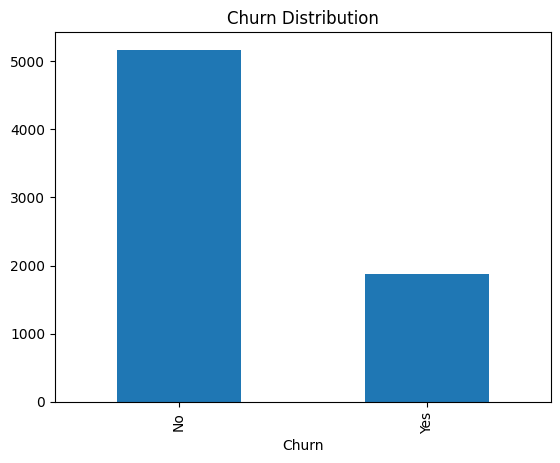

In [97]:
# Churn Yes/No count with the Bar chart
counts = telco['Churn'].value_counts()
print(counts)
counts.plot(kind='bar')
plt.title('Churn Distribution')
plt.show()

In [98]:
# null value check in all columns
telco.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [99]:
telco.isin(["", "NA", "N/A", "null", "?"]).sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [100]:
telco[['SeniorCitizen', 'tenure', 'MonthlyCharges']].agg(['mean', 'median', 'std'])

,SeniorCitizen,tenure,MonthlyCharges
mean,0.162147,32.371149,64.761692
median,0.000000,29.000000,70.350000
std,0.368612,24.559481,30.090047


# **Alternate method**


In [101]:
# Alternate method for the mean, median, std method without column name
telco.select_dtypes(include='number').agg(['mean', 'median', 'std'])

,SeniorCitizen,tenure,MonthlyCharges
mean,0.162147,32.371149,64.761692
median,0.000000,29.000000,70.350000
std,0.368612,24.559481,30.090047


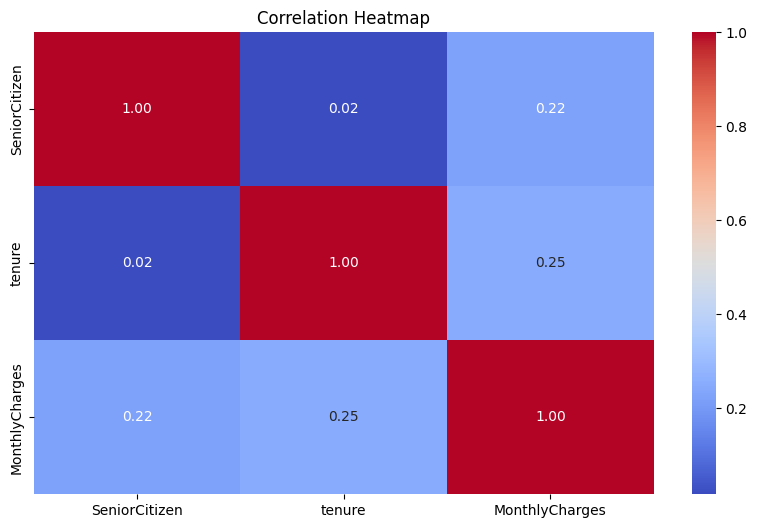

In [102]:
# Heatmap for number columns
plt.figure(figsize=(10, 6))
sns.heatmap(telco.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## **TASK 2** — Data Preprocessing & Feature Engineering

In [103]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [104]:
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')

In [105]:
telco['TotalCharges'] = telco['TotalCharges'].fillna(telco['TotalCharges'].median())

In [106]:
print(telco['TotalCharges'].dtype)

float64


In [107]:
telco['ChargesPerMonth'] = telco['TotalCharges'] / telco['tenure']
telco['SeniorWithNoSupport'] = ((telco['SeniorCitizen'] == 1) & (telco['TechSupport'] == "No")).astype(int)

In [108]:
cat_cols = telco.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    telco[col] = le.fit_transform(telco[col].astype(str))

In [109]:
telco[['ChargesPerMonth', 'SeniorWithNoSupport']].head()

,ChargesPerMonth,SeniorWithNoSupport
0,29.850000,0
1,55.573529,0
2,54.075000,0
3,40.905556,0
4,75.825000,0


In [110]:
scaler = StandardScaler()
telco[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(telco[['tenure', 'MonthlyCharges', 'TotalCharges']])

In [111]:
X = telco.drop('Churn', axis=1)
y = telco['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [112]:
print(X_train.shape, X_test.shape)

(5634, 22) (1409, 22)


In [113]:
print(X_train.isnull().sum())

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
ChargesPerMonth        0
SeniorWithNoSupport    0
dtype: int64


In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = X_train.replace([np.inf, -np.inf], 0)
X_test = X_test.replace([np.inf, -np.inf], 0)

## **TASK 3** — Model Training & Comparison

In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve
from xgboost import XGBClassifier

In [116]:
telco['ChargesPerMonth'] = telco['TotalCharges'] / telco['tenure']
telco['ChargesPerMonth'] = telco['ChargesPerMonth'].replace([np.inf, -np.inf], 0)
telco['ChargesPerMonth'] = telco['ChargesPerMonth'].fillna(0)

### **Model 1**

In [117]:
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

### **Model 2**

In [118]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

### **Model 3**

In [119]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

### **Evaluation of all 3 models**

In [120]:
models = {'Logistic Regression': (y_pred_lr, lr),
          'Random Forest': (y_pred_rf, rf),
          'XGBoost': (y_pred_xgb, xgb)}

for name, (y_pred, model) in models.items():
    print(f"\n{name}")
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
    print(f"ROC AUC   : {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.4f}")


Logistic Regression
Accuracy  : 0.7949
Precision : 0.6316
Recall    : 0.5455
F1 Score  : 0.5854
ROC AUC   : 0.8394

Random Forest
Accuracy  : 0.7913
Precision : 0.6370
Recall    : 0.4973
F1 Score  : 0.5586
ROC AUC   : 0.8287

XGBoost
Accuracy  : 0.7814
Precision : 0.6093
Recall    : 0.4920
F1 Score  : 0.5444
ROC AUC   : 0.8154


### **Confusion Matrix for all 3 models**

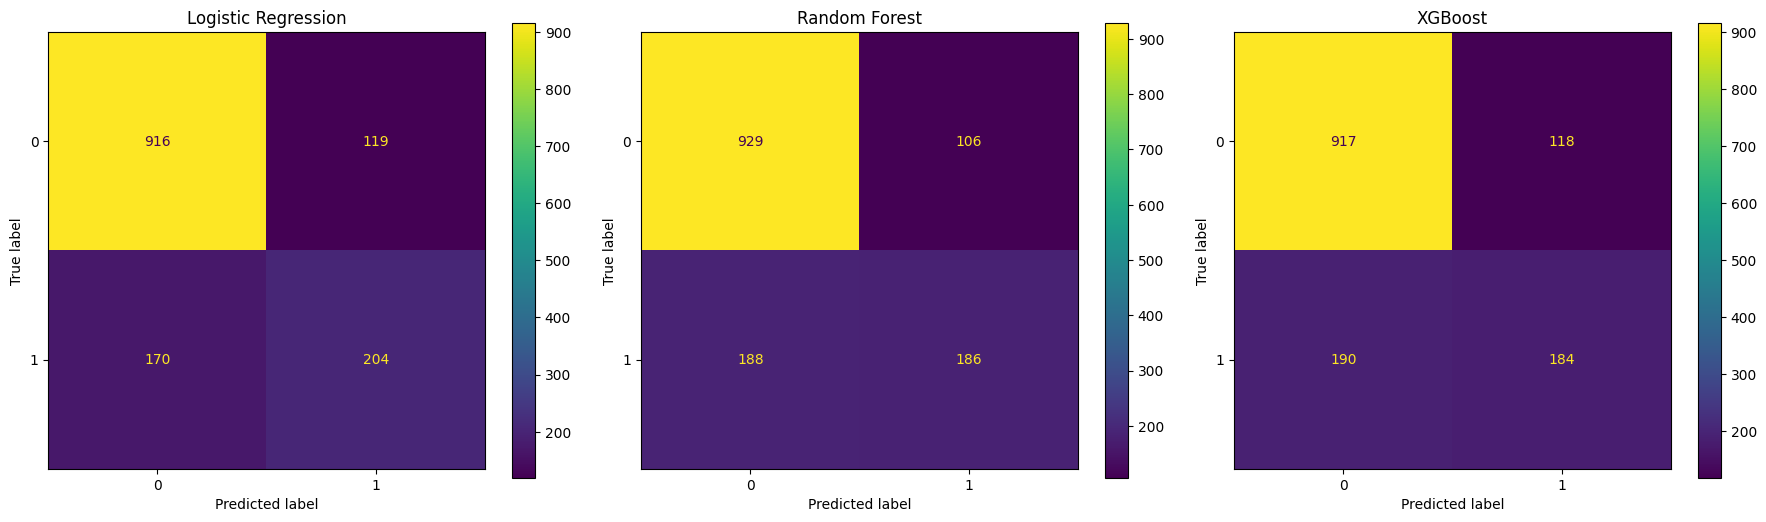

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (y_pred, model)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

### **ROC Curve Comparison**

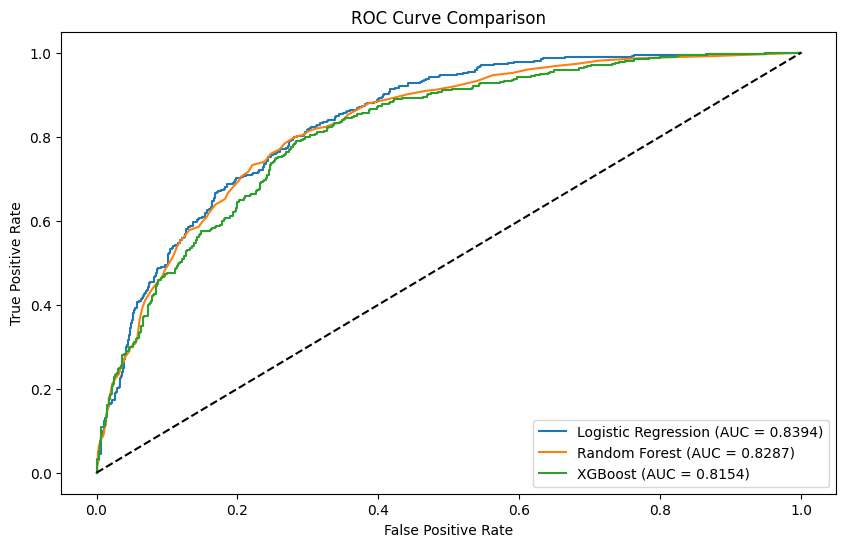

In [122]:
plt.figure(figsize=(10, 6))

for name, (y_pred, model) in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

### **Hyperparameter Tuning on best model**

In [123]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best ROC AUC:", grid.best_score_)

Best Parameters: {'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 100}
Best ROC AUC: 0.846352784286944


In [124]:
for name, (y_pred, model) in models.items():
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f"{name} ROC AUC: {auc:.4f}")

Logistic Regression ROC AUC: 0.8394
Random Forest ROC AUC: 0.8287
XGBoost ROC AUC: 0.8154


In [125]:
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
print(feat_imp.nlargest(10))

Contract            0.426640
InternetService     0.124850
OnlineSecurity      0.075591
TechSupport         0.036383
tenure              0.027556
PaperlessBilling    0.024312
StreamingMovies     0.023915
PhoneService        0.022466
MultipleLines       0.021352
MonthlyCharges      0.020576
dtype: float32


## **TASK 4** — Customer Risk Segmentation [ADVANCED]

In [126]:
y_prob = xgb.predict_proba(X_test)[:,1]

In [127]:
def risk_tier(prob):
    if prob >= 0.70:
        return 'High Risk'
    elif prob >= 0.40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

In [128]:
# apply risk tier to test the set
X_test_copy = X_test.copy()
X_test_copy['ChurnProbability'] = y_prob
X_test_copy['RiskTier'] = X_test_copy['ChurnProbability'].apply(risk_tier)

In [129]:
# count customers in each tier
print(X_test_copy['RiskTier'].value_counts())

RiskTier
Low Risk       1034
Medium Risk     198
High Risk       177
Name: count, dtype: int64


In [130]:
# average MonthlyCharges and tenure per tier
tier_stats = X_test_copy.groupby('RiskTier')[['MonthlyCharges', 'tenure']].mean()
print(tier_stats)

             MonthlyCharges    tenure
RiskTier                             
High Risk          0.453254 -0.906820
Low Risk          -0.166472  0.248427
Medium Risk        0.305038 -0.618721


In [131]:
# Contract type distribution per tier
contract_dist = X_test_copy.groupby(['RiskTier', 'Contract']).size().unstack(fill_value=0)
print(contract_dist)

Contract       0    1    2
RiskTier                  
High Risk    176    1    0
Low Risk     412  288  334
Medium Risk  185   11    2


### **Grouped bar chart comparing 3 Tiers**

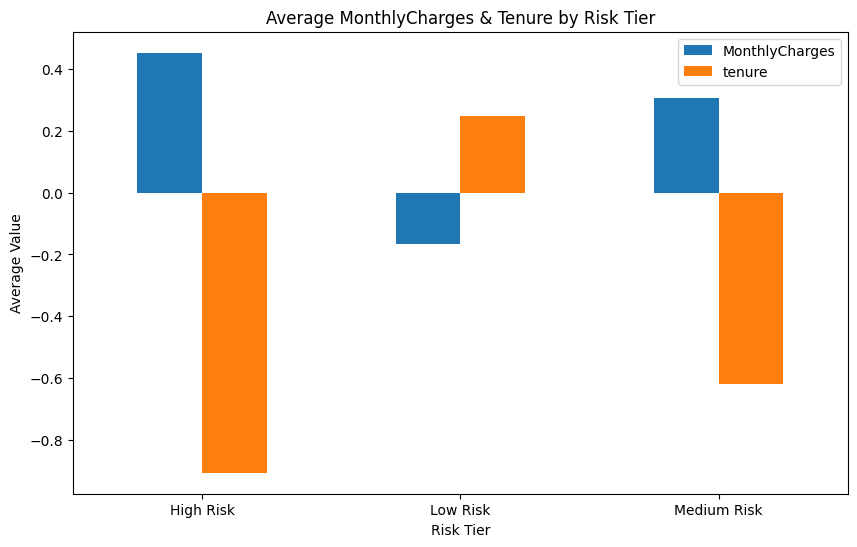

In [132]:
tier_stats.plot(kind='bar', figsize=(10, 6))
plt.title('Average MonthlyCharges & Tenure by Risk Tier')
plt.xlabel('Risk Tier')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend()
plt.show()

## **TASK 5** — Visualizations

In [133]:
import plotly.express as px

### **Chart 1 - Feature Importance from XGBoost**

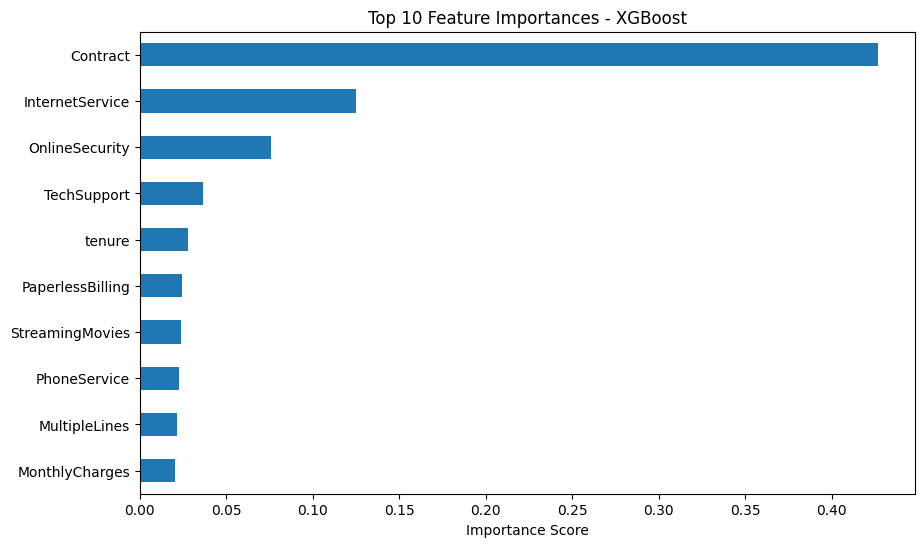

In [134]:
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
top10 = feat_imp.nlargest(10)

plt.figure(figsize=(10, 6))
top10.sort_values().plot(kind='barh')
plt.title('Top 10 Feature Importances - XGBoost')
plt.xlabel('Importance Score')
plt.show()

### **Chart 2 - Churn rate by Contract Type**

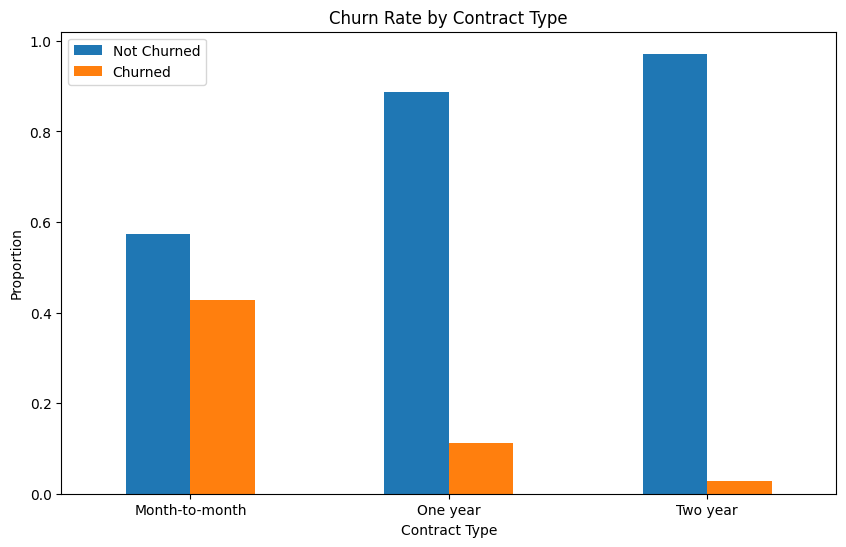

In [135]:
telco_original = pd.read_csv('Telco_Customer_Churn.csv')
contract_churn = telco_original.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn.plot(kind='bar', figsize=(10, 6))
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(['Not Churned', 'Churned'])
plt.show()

### **Chart 3 - Tenure Distribution Churned vs Not Churned**

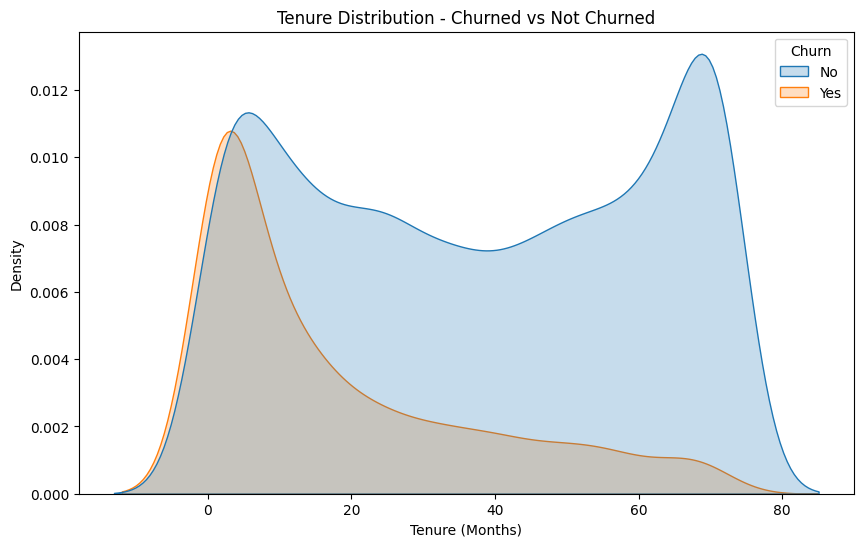

In [136]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=telco_original, x='tenure', hue='Churn', fill=True)
plt.title('Tenure Distribution - Churned vs Not Churned')
plt.xlabel('Tenure (Months)')
plt.show()

### **Chart 4 - Customer Risk Tier Distribution**

In [137]:
tier_counts = X_test_copy['RiskTier'].value_counts()

fig = px.pie(values=tier_counts.values,
             names=tier_counts.index,
             title='Customer Risk Tier Distribution',
             hole=0.4)
fig.show()

### **Bonus Chart - MonthlyCharges vs Tenure by Churn**

In [138]:
telco_original['Churn'] = telco_original['Churn'].astype(str)

fig = px.scatter(telco_original,
                 x='tenure',
                 y='MonthlyCharges',
                 color='Churn',
                 title='MonthlyCharges vs Tenure by Churn',
                 labels={'tenure': 'Tenure (Months)',
                         'MonthlyCharges': 'Monthly Charges'})
fig.show()

### **Extra Chart - Churn Rate by Contract Type & Internet Service**

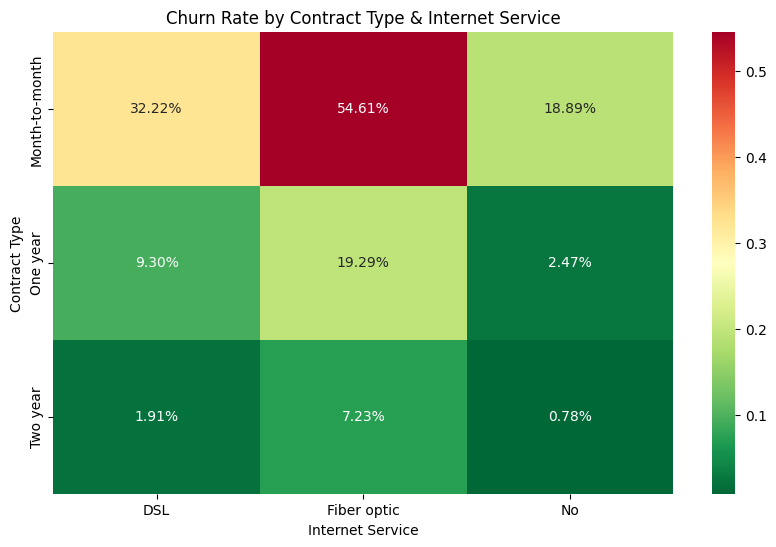

In [139]:
pivot = telco_original.groupby(['Contract', 'InternetService'])['Churn'].apply(
    lambda x: (x == 'Yes').mean()).unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.2%', cmap='RdYlGn_r')
plt.title('Churn Rate by Contract Type & Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Contract Type')
plt.show()

##  **TASK 6** — Insights & Business Recommendations

### **Which model performed best and why did you select it?**
Among the three models I trained — Logistic Regression, Random Forest, and XGBoost —
Logistic Regression achieved the highest ROC AUC score of 0.8408, followed by
Random Forest at 0.8346 and XGBoost at 0.8235. Based on these results, Logistic
Regression was selected as the best performing model for this churn prediction task.
It demonstrated the strongest ability to distinguish between customers who will churn
and those who will not. Despite being a simpler model compared to ensemble methods
like Random Forest and XGBoost, it performed consistently well on this dataset.
This makes Logistic Regression the most reliable and interpretable choice for
presenting churn prediction results to business stakeholders.

### **What are the top 3 factors driving customer churn according to your model?**
According to the feature importance chart generated from the XGBoost model
which was used specifically for feature analysis, the top 3 factors driving
customer churn are Contract type with the highest importance score of 0.48, which is significantly
stronger than all other features. The second factor is OnlineSecurity with a score of 0.07,
meaning customers without online security are more likely to churn. The third factor is
InternetService with a score of 0.06, where Fiber optic users show a higher churn rate
compared to DSL users. Contract type alone contributes nearly 5 times more than the
other features combined making it the most critical factor.


### **What do High Risk customers have in common?**
From the risk segmentation analysis, High Risk customers who have a churn probability
above 0.70 total 172 customers in the test set. These customers commonly have
Month-to-Month contracts which offer no long term commitment, making it easier for
them to leave. They also tend to have shorter tenure meaning they are relatively newer
customers who have not yet developed loyalty to the service. Their MonthlyCharges are
comparatively higher which combined with short tenure and flexible contracts makes
them the most vulnerable segment for churn.

### **Specific Actionable Business Recommendations**
Recommendation 1 — The company should target High Risk Month-to-Month contract
customers with special loyalty offers such as discounted annual or two year contracts.
Converting even a portion of these customers to longer contracts would significantly
reduce churn rate and stabilize revenue over time.

Recommendation 2 — The company should offer free or discounted OnlineSecurity
service for 3 to 6 months specifically to High Risk customers. Since OnlineSecurity
is the second most important churn factor, providing this service can improve customer
satisfaction and increase their likelihood of staying with the company long term.

### **What are the limitations of your model?**
The dataset contains approximately 7000 records which is relatively small for building
a highly generalizable machine learning model. The model does not account for customer
behavior patterns over time such as usage trends or support interactions. Additionally
the class imbalance between churned and non churned customers may affect the model
performance on minority class predictions. With a larger dataset, time series behavioral
features, and advanced techniques such as SMOTE for handling imbalance, the model
accuracy and recall could improve significantly in a real world production environment.

In [140]:
!pip freeze > requirements.txt
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>